TASK-01


Download link: https://drive.google.com/uc?id=1bTAgEjug-zC5Iso4GJe8xoMzWp1AEwxH

First 5 rows of the dataset:
        ID  Clump  UnifSize  UnifShape  MargAdh  SingEpiSize  BareNuc  \
0  1000025      5         1          1        1            2        1   
1  1002945      5         4          4        5            7       10   
2  1015425      3         1          1        1            2        2   
3  1016277      6         8          8        1            3        4   
4  1017023      4         1          1        3            2        1   

   BlandChrom  NormNucl  Mit  Class  
0           3         1    1      0  
1           3         2    1      0  
2           3         1    1      0  
3           3         7    1      0  
4           3         1    1      0  

Dataset shape (rows, columns): (699, 11)

Column names: ['ID', 'Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit', 'Class']

Data types of each column:
ID             int

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.0225 - loss: 1.4569 - val_accuracy: 0.0804 - val_loss: 1.3115
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0270 - loss: 1.3296 - val_accuracy: 0.0893 - val_loss: 1.2441
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0226 - loss: 1.2362 - val_accuracy: 0.0893 - val_loss: 1.1794
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0271 - loss: 1.1861 - val_accuracy: 0.0804 - val_loss: 1.1178
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0357 - loss: 1.1478 - val_accuracy: 0.0893 - val_loss: 1.0594
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0532 - loss: 1.0545 - val_accuracy: 0.0893 - val_loss: 1.0038
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0825 - loss: 1.0037 - val_accuracy: 0.1071 - val_loss: 0.9517
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0989 - loss: 0.9511 - val_accuracy: 0.1250 - val_loss: 0.9023

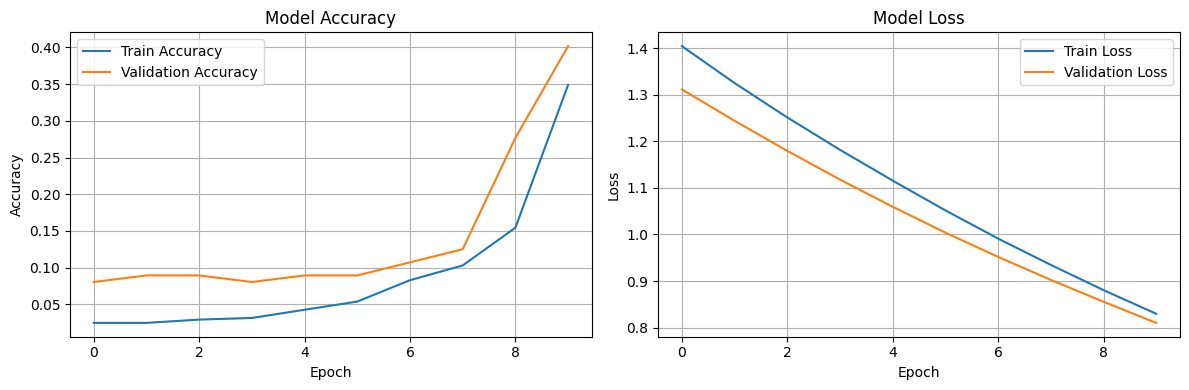

In [ ]:
import pandas as pd
import numpy as np

file_link = 'https://drive.google.com/file/d/1bTAgEjug-zC5Iso4GJe8xoMzWp1AEwxH/view?usp=sharing'

file_id = file_link.split("/")[-2]

download_link = f'https://drive.google.com/uc?id={file_id}'
print("Download link:", download_link)

df = pd.read_csv(download_link)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types of each column:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print("\nAny missing values?")
print(df.isnull().sum())


df = df.drop(columns=['ID'])


X = df.drop(columns=['Class'])


y = df['Class']

print("\nFeature matrix shape:", X.shape)
print("Label shape:", y.shape)
print("Class distribution (0=benign, 1=malignant):")
print(y.value_counts())


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("\n--- Classical ML Models ---")


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
print(f"Logistic Regression Accuracy : {accuracy_score(y_test, lr_pred):.4f}")

nb = GaussianNB()
nb.fit(X_train_s, y_train)
nb_pred = nb.predict(X_test_s)
print(f"Naive Bayes Accuracy         : {accuracy_score(y_test, nb_pred):.4f}")


rf = RandomForestClassifier()
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)
print(f"Random Forest Accuracy       : {accuracy_score(y_test, rf_pred):.4f}")


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("\n--- Building Keras Neural Network ---")


model = keras.Sequential([

    layers.Dense(10, activation='relu', input_shape=(X_train_s.shape[1],)),


    layers.Dense(1, activation='sigmoid')
])


model.summary()


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


history = model.fit(
    X_train_s, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")

from matplotlib import pyplot as plt


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],    label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],    label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


TASK-02


SMS dataset loaded!
Shape: (5572, 2)

First 5 rows:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Class distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64

Label classes: ['ham' 'spam']

Shape of padded input: (5572, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8697 - loss: 0.4002 - val_accuracy: 0.8576 - val_loss: 0.2229
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8945 - loss: 0.1716 - val_accuracy: 0.9574 - val_loss: 0.1637
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9783 - loss: 0.1276 - val_accuracy: 0.9720 - val_loss: 0.1294
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9875 - loss: 0.0677 - val_accuracy: 0.9787 - val_loss: 0.0676
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9956 - loss: 0.0180 - val_accuracy: 0.9809 - val_loss: 0.0667
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9976 - loss: 0.0135 - val_accuracy: 0.9821 - val_loss: 0.0637
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9994 - loss: 0.0059 - val_accuracy: 0.9821 - val_loss: 0.0698
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9998 - loss: 0.0037 - val_accuracy: 0.9821 - val_lo

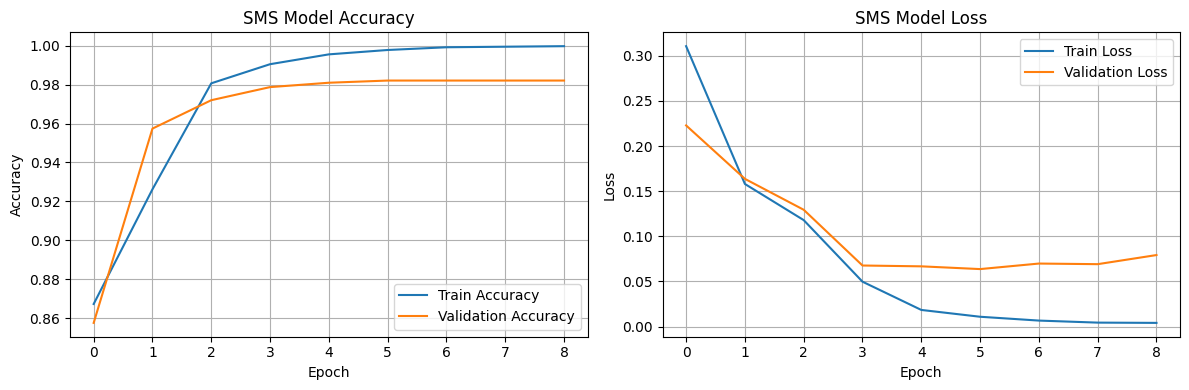

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df_sms = pd.read_csv(url, sep='\t', header=None, names=['Category', 'Message'])

print("SMS dataset loaded!")
print(f"Shape: {df_sms.shape}")
print("\nFirst 5 rows:")
print(df_sms.head())
print("\nClass distribution:")
print(df_sms['Category'].value_counts())


le = LabelEncoder()
df_sms['Category'] = le.fit_transform(df_sms['Category'])

print("\nLabel classes:", le.classes_)


tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")


tokenizer.fit_on_texts(df_sms['Message'])

X_seq = tokenizer.texts_to_sequences(df_sms['Message'])

X_pad = pad_sequences(X_seq, maxlen=100, padding='post', truncating='post')

y_sms = df_sms['Category'].values

print(f"\nShape of padded input: {X_pad.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_sms, test_size=0.2, random_state=42
)

model_sms = keras.Sequential([

    layers.Embedding(input_dim=5000, output_dim=16, input_length=100),


    layers.Flatten(),

    layers.Dense(64, activation='relu'),


    layers.Dense(1, activation='sigmoid')
])

model_sms.summary()


model_sms.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])


es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


history_sms = model_sms.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


loss, acc = model_sms.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")


y_prob = model_sms.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

from matplotlib import pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_sms.history['accuracy'],     label='Train Accuracy')
plt.plot(history_sms.history['val_accuracy'], label='Validation Accuracy')
plt.title('SMS Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_sms.history['loss'],     label='Train Loss')
plt.plot(history_sms.history['val_loss'], label='Validation Loss')
plt.title('SMS Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


TASK-03


Iris Dataset loaded!
Feature matrix shape : (150, 4)
Label shape          : (150,)
Class names          : ['setosa' 'versicolor' 'virginica']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3289 - loss: 1.0949 - val_accuracy: 0.2500 - val_loss: 1.0483
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5202 - loss: 0.9769 - val_accuracy: 0.6667 - val_loss: 0.9305
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5615 - loss: 0.9207 - val_accuracy: 0.6667 - val_loss: 0.8294
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6915 - loss: 0.7339 - val_accuracy: 0.7083 - val_loss: 0.7432
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6390 - loss: 0.6881 - val_accuracy: 0.7500 - val_loss: 0.6768
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7302 - loss: 0.6149 - val_accuracy: 0.7500 - val_loss: 0.6198
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7760 - loss: 0.5409 - val_accuracy: 0.7917 - val_loss: 0.5722
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8080 - loss: 0.5201 - val_accuracy: 0.7500 - val_loss: 0.5301


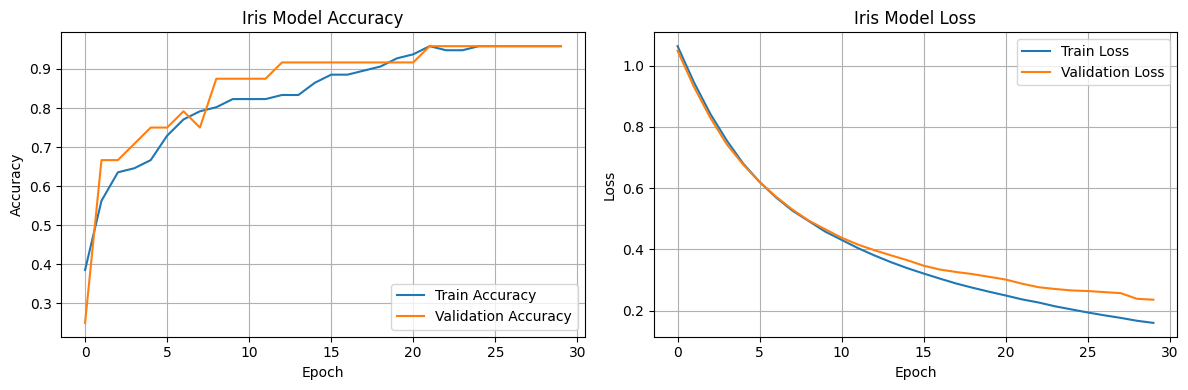

In [ ]:

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt


iris = load_iris()
X = iris.data
y = iris.target

print("Iris Dataset loaded!")
print(f"Feature matrix shape : {X.shape}")
print(f"Label shape          : {y.shape}")
print(f"Class names          : {iris.target_names}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=3)

model_iris = keras.Sequential([

    layers.Dense(64, activation='relu', input_shape=(4,)),

    layers.Dense(32, activation='relu'),

    layers.Dense(3, activation='softmax')
])

model_iris.summary()


model_iris.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_iris = model_iris.fit(
    X_train_s, y_train_oh,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

loss, acc = model_iris.evaluate(X_test_s, y_test_oh, verbose=0)
print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")

y_pred_prob = model_iris.predict(X_test_s)       # probability for each class
y_pred_class = np.argmax(y_pred_prob, axis=1)

print(f"\nSample Predictions : {y_pred_class[:10]}")
print(f"Actual Labels      : {y_test[:10]}")
print(f"Sklearn Accuracy   : {accuracy_score(y_test, y_pred_class):.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_iris.history['accuracy'],     label='Train Accuracy')
plt.plot(history_iris.history['val_accuracy'], label='Validation Accuracy')
plt.title('Iris Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_iris.history['loss'],     label='Train Loss')
plt.plot(history_iris.history['val_loss'], label='Validation Loss')
plt.title('Iris Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
